# 03_clustering.ipynb

## End-to-End Machine Learning Clustering Pipeline for Credit Card Customer Segmentation

This notebook implements a complete end-to-end **Machine Learning clustering pipeline** using `clusteringmidterm.csv`.

**Objective:** group credit card customers based on spending behavior, cash advance usage, payment behavior, credit limit, balance, and account tenure.

Unlike classification or regression, clustering is an **unsupervised learning task**, meaning there is no target label. The goal is to discover meaningful customer groups from patterns in the data.

**Main workflow:**
1. Environment setup and library import
2. Dataset loading from Google Drive
3. Exploratory Data Analysis (EDA)
4. Missing value handling
5. Outlier handling
6. Feature preparation
7. Feature scaling
8. Choosing the number of clusters
9. Hyperparameter tuning using Optuna
10. K-Means model training
11. Cluster evaluation
12. Cluster visualization using PCA
13. Cluster profiling and interpretation
14. Experiment tracking using MLflow
15. Final conclusion

> This notebook includes clear markdown explanations and code comments for each step of the clustering process, so the reasoning behind every decision is easy to follow.

In [1]:
# ============================================================
# 1. Install required dependencies if missing
# ============================================================
# Optuna is used to search for the best number of clusters.
# MLflow is used to track clustering parameters, metrics, and artifacts.

import sys
import subprocess
import importlib.util


def install_if_missing(package_name, import_name=None):
    """Install a package only if it is not already available."""
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("optuna")
install_if_missing("mlflow")

Installing optuna ...
Installing mlflow ...


In [2]:
# ============================================================
# 2. Import libraries
# ============================================================
# The libraries below cover data manipulation, visualization,
# preprocessing, clustering, dimensionality reduction, tuning, and tracking.

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import optuna
import mlflow

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The dataset is loaded from Google Drive using this path:

```python
/content/drive/MyDrive/clusteringmidterm.csv
```

The dataset contains customer credit card behavior features such as balance, purchases, cash advance, payments, minimum payments, credit limit, full payment ratio, and tenure.

In [3]:
# ============================================================
# 3. Mount Google Drive and load the clustering dataset
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception:
    print("Google Drive is already mounted or this is not a Colab environment.")

DATA_PATH = "/content/drive/MyDrive/clusteringmidterm.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}. Please make sure clusteringmidterm.csv is located in MyDrive."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Mounted at /content/drive
Google Drive mounted successfully.
Dataset loaded successfully.
Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 4. Exploratory Data Analysis

EDA is performed to understand the dataset structure, data types, missing values, and basic statistical characteristics. This step is important because clustering algorithms are sensitive to feature scale, missing values, and extreme outliers.

In [4]:
# ============================================================
# 4. Basic EDA
# ============================================================

print("Dataset information:")
print(df.info())

print("Statistical summary of numerical columns:")
display(df.describe().T)

print("First five rows:")
display(df.head())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


First five rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
# ============================================================
# 5. Missing value analysis
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

print("Missing value summary:")
display(missing_summary)

Missing value summary:


,missing_count,missing_ratio
MINIMUM_PAYMENTS,313,0.034972
CREDIT_LIMIT,1,0.000112
BALANCE,0,0.000000
CUST_ID,0,0.000000
BALANCE_FREQUENCY,0,0.000000
PURCHASES,0,0.000000
CASH_ADVANCE,0,0.000000
PURCHASES_FREQUENCY,0,0.000000
ONEOFF_PURCHASES,0,0.000000
INSTALLMENTS_PURCHASES,0,0.000000


## 5. Feature Preparation

For clustering, identifier columns should not be used as features because identifiers do not represent behavioral patterns. Therefore, `CUST_ID` is removed if it exists.

Only numerical variables are used for clustering because K-Means, DBSCAN, and hierarchical clustering rely on numerical distances.

In [6]:
# ============================================================
# 6. Prepare numerical features
# ============================================================

ID_COLS = [col for col in ["CUST_ID"] if col in df.columns]

# Drop customer identifier columns from modeling features.
feature_df = df.drop(columns=ID_COLS, errors="ignore").copy()

# Convert all feature columns to numeric when possible.
for col in feature_df.columns:
    feature_df[col] = pd.to_numeric(feature_df[col], errors="coerce")

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
feature_df = feature_df[numeric_cols].copy()

# Remove constant columns because they cannot help separate clusters.
constant_cols = [col for col in feature_df.columns if feature_df[col].nunique(dropna=True) <= 1]
if len(constant_cols) > 0:
    feature_df = feature_df.drop(columns=constant_cols)

numeric_cols = feature_df.columns.tolist()

print("Removed ID columns:", ID_COLS)
print("Removed constant columns:", len(constant_cols))
print("Number of numerical features used:", len(numeric_cols))
print("Feature matrix shape:", feature_df.shape)

gc.collect()

Removed ID columns: ['CUST_ID']
Removed constant columns: 0
Number of numerical features used: 17
Feature matrix shape: (8950, 17)


150

## 6. Outlier Handling

Credit card behavior data often contains extreme values, such as very high purchases or cash advances. These outliers can dominate distance-based clustering.

This notebook uses quantile clipping to reduce the impact of extreme values while preserving the overall structure of the data.

In [7]:
# ============================================================
# 7. Outlier handling using quantile clipping
# ============================================================

LOWER_Q = 0.01
UPPER_Q = 0.99

lower_bounds = feature_df.quantile(LOWER_Q)
upper_bounds = feature_df.quantile(UPPER_Q)

feature_df_clipped = feature_df.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

print("Outlier clipping completed.")
print(f"Lower quantile: {LOWER_Q}")
print(f"Upper quantile: {UPPER_Q}")

Outlier clipping completed.
Lower quantile: 0.01
Upper quantile: 0.99


## 7. Preprocessing: Missing Value Handling and Scaling

Clustering algorithms are sensitive to feature scale. For example, a feature like `PURCHASES` may have a much larger numerical range than a frequency feature such as `PRC_FULL_PAYMENT`.

The preprocessing pipeline applies:

1. Median imputation for missing values.
2. Standard scaling to make features comparable.

In [8]:
# ============================================================
# 8. Preprocessing pipeline
# ============================================================

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessor.fit_transform(feature_df_clipped)

print("Preprocessing completed successfully.")
print("Scaled feature matrix shape:", X_scaled.shape)

Preprocessing completed successfully.
Scaled feature matrix shape: (8950, 17)


## 8. Choosing the Number of Clusters

The number of clusters is selected using multiple clustering quality indicators:

- **Inertia / Elbow Method:** measures within-cluster compactness. Lower is better, but the goal is to find the elbow point.
- **Silhouette Score:** measures how well-separated clusters are. Higher is better.
- **Davies-Bouldin Score:** measures cluster separation and compactness. Lower is better.
- **Calinski-Harabasz Score:** measures cluster separation. Higher is better.

Using multiple metrics gives a more reliable clustering decision than relying on a single score.

In [9]:
# ============================================================
# 9. Evaluate candidate numbers of clusters
# ============================================================

candidate_k = list(range(2, 11))
cluster_eval_results = []

for k in candidate_k:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)

    cluster_eval_results.append({
        "n_clusters": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette,
        "davies_bouldin_score": db_score,
        "calinski_harabasz_score": ch_score
    })

cluster_eval_df = pd.DataFrame(cluster_eval_results)
display(cluster_eval_df)

,n_clusters,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,123745.334439,0.304141,1.637636,2053.936467
1,3,104003.905398,0.255383,1.534503,2070.899337
2,4,91368.717218,0.195243,1.591835,1983.724469
3,5,84429.886903,0.189804,1.488954,1793.667288
4,6,78540.140424,0.200303,1.573799,1676.510026
5,7,73360.945748,0.211479,1.451165,1600.785228
6,8,69545.495396,0.218521,1.397313,1517.299628
7,9,66495.489556,0.198881,1.503537,1439.645519
8,10,63513.884382,0.200087,1.521669,1386.235609


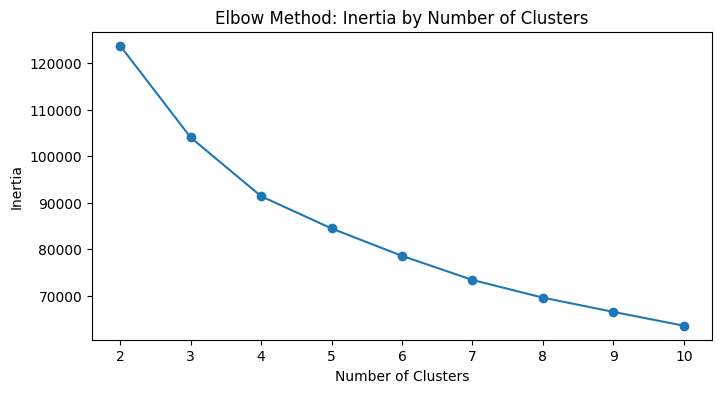

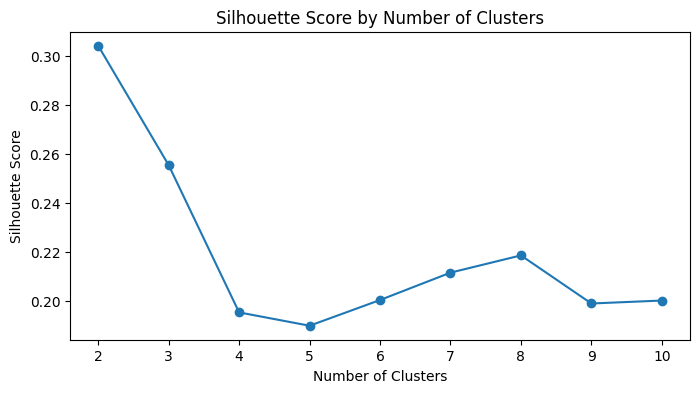

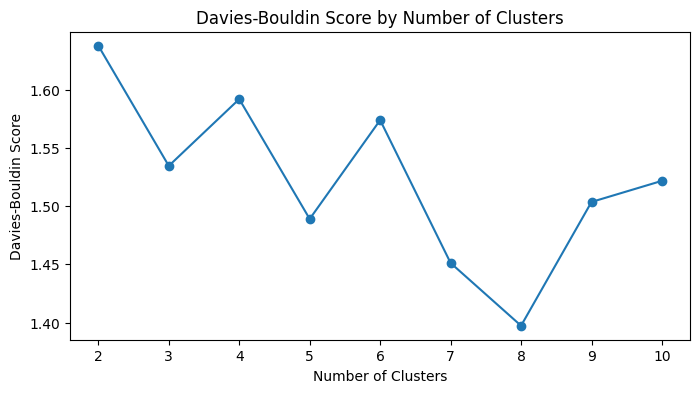

In [10]:
# ============================================================
# 10. Visualize clustering metric trends
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(cluster_eval_df["n_clusters"], cluster_eval_df["inertia"], marker="o")
plt.title("Elbow Method: Inertia by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(candidate_k)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cluster_eval_df["n_clusters"], cluster_eval_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(candidate_k)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cluster_eval_df["n_clusters"], cluster_eval_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(candidate_k)
plt.show()

## 9. Hyperparameter Tuning with Optuna

Although clustering is unsupervised, Optuna can still be used to search for the number of clusters that maximizes the Silhouette Score.

The objective function trains K-Means with different values of `n_clusters` and returns the Silhouette Score. The best value is then used for the final K-Means model.

In [11]:
# ============================================================
# 11. Optuna tuning for K-Means number of clusters
# ============================================================

N_TRIALS = 20


def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 2, 10)
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return score

study = optuna.create_study(direction="maximize", study_name="clustering_kmeans_tuning")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best_k = study.best_params["n_clusters"]
print("Best number of clusters:", best_k)
print("Best silhouette score:", study.best_value)

[I 2026-05-15 12:39:57,816] A new study created in memory with name: clustering_kmeans_tuning
[I 2026-05-15 12:40:00,133] Trial 0 finished with value: 0.20008696755977373 and parameters: {'n_clusters': 10}. Best is trial 0 with value: 0.20008696755977373.
[I 2026-05-15 12:40:01,404] Trial 1 finished with value: 0.255383424459191 and parameters: {'n_clusters': 3}. Best is trial 1 with value: 0.255383424459191.
[I 2026-05-15 12:40:02,902] Trial 2 finished with value: 0.20008696755977373 and parameters: {'n_clusters': 10}. Best is trial 1 with value: 0.255383424459191.
[I 2026-05-15 12:40:04,380] Trial 3 finished with value: 0.19888127901964547 and parameters: {'n_clusters': 9}. Best is trial 1 with value: 0.255383424459191.
[I 2026-05-15 12:40:05,805] Trial 4 finished with value: 0.218521164698979 and parameters: {'n_clusters': 8}. Best is trial 1 with value: 0.255383424459191.
[I 2026-05-15 12:40:07,270] Trial 5 finished with value: 0.19888127901964547 and parameters: {'n_clusters': 9}.

Best number of clusters: 2
Best silhouette score: 0.3041409982878425


## 10. Final K-Means Model Training

K-Means is selected as the main clustering model because it is simple, widely used, computationally efficient, and suitable as a baseline for customer segmentation.

The final model uses the number of clusters selected by Optuna.

In [12]:
# ============================================================
# 12. Train final K-Means model
# ============================================================

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

clustered_df = df.copy()
clustered_df["cluster"] = final_labels

print("Final K-Means model trained successfully.")
print("Cluster distribution:")
display(clustered_df["cluster"].value_counts().sort_index().to_frame("count"))

Final K-Means model trained successfully.
Cluster distribution:


,count
cluster,
0,1649
1,7301


## 11. Final Cluster Evaluation

The final clustering result is evaluated using multiple internal clustering metrics. Since clustering has no true target label, internal evaluation metrics are used to assess compactness and separation.

In [13]:
# ============================================================
# 13. Final cluster evaluation
# ============================================================

final_silhouette = silhouette_score(X_scaled, final_labels)
final_db = davies_bouldin_score(X_scaled, final_labels)
final_ch = calinski_harabasz_score(X_scaled, final_labels)
final_inertia = final_kmeans.inertia_

final_metrics = {
    "n_clusters": best_k,
    "inertia": final_inertia,
    "silhouette_score": final_silhouette,
    "davies_bouldin_score": final_db,
    "calinski_harabasz_score": final_ch
}

print("Final clustering metrics:")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}" if isinstance(metric_value, float) else f"{metric_name}: {metric_value}")

Final clustering metrics:
n_clusters: 2
inertia: 123745.3344
silhouette_score: 0.3041
davies_bouldin_score: 1.6376
calinski_harabasz_score: 2053.9365


## 12. Alternative Clustering Models for Comparison

To make the clustering analysis more complete, this notebook also tests two alternative unsupervised methods:

- **Agglomerative Clustering:** a hierarchical clustering method.
- **DBSCAN:** a density-based clustering method.

These models are used as comparisons, while K-Means remains the final selected model because it is stable and easier to interpret for customer segmentation.

In [14]:
# ============================================================
# 14. Alternative clustering comparison on a safe sample
# ============================================================
# Hierarchical and DBSCAN can be slower or less stable on large datasets.
# Therefore, a sample is used for comparison only.

ALT_SAMPLE_SIZE = min(3000, X_scaled.shape[0])
alt_indices = np.random.RandomState(RANDOM_STATE).choice(X_scaled.shape[0], size=ALT_SAMPLE_SIZE, replace=False)
X_alt = X_scaled[alt_indices]

alternative_results = []

# Agglomerative Clustering
agg_model = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg_model.fit_predict(X_alt)
alternative_results.append({
    "model": "AgglomerativeClustering",
    "n_clusters_or_groups": len(np.unique(agg_labels)),
    "silhouette_score": silhouette_score(X_alt, agg_labels),
    "davies_bouldin_score": davies_bouldin_score(X_alt, agg_labels),
    "calinski_harabasz_score": calinski_harabasz_score(X_alt, agg_labels)
})

# DBSCAN
# DBSCAN may generate noise points labeled as -1.
dbscan_model = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan_model.fit_predict(X_alt)
unique_dbscan_labels = np.unique(dbscan_labels)

if len(unique_dbscan_labels) > 1 and len(set(unique_dbscan_labels) - {-1}) >= 1:
    alternative_results.append({
        "model": "DBSCAN",
        "n_clusters_or_groups": len(unique_dbscan_labels),
        "silhouette_score": silhouette_score(X_alt, dbscan_labels),
        "davies_bouldin_score": davies_bouldin_score(X_alt, dbscan_labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_alt, dbscan_labels)
    })
else:
    alternative_results.append({
        "model": "DBSCAN",
        "n_clusters_or_groups": len(unique_dbscan_labels),
        "silhouette_score": np.nan,
        "davies_bouldin_score": np.nan,
        "calinski_harabasz_score": np.nan
    })

alternative_results_df = pd.DataFrame(alternative_results)
display(alternative_results_df)

,model,n_clusters_or_groups,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,AgglomerativeClustering,2,0.200056,2.027848,581.970864
1,DBSCAN,4,-0.042366,2.095376,141.852971


## 13. Cluster Visualization with PCA

Because the dataset has many features, PCA is used to reduce the scaled feature space into two dimensions. This visualization does not train the clustering model; it only helps display the cluster structure in a human-readable 2D plot.

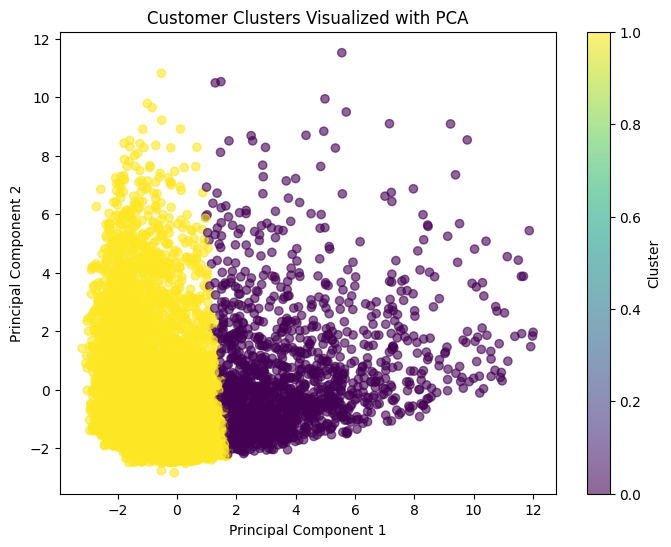

Explained variance ratio by PCA components:
[0.29340782 0.21962087]


In [15]:
# ============================================================
# 15. PCA visualization
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": final_labels
})

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["cluster"], alpha=0.6)
plt.title("Customer Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

print("Explained variance ratio by PCA components:")
print(pca.explained_variance_ratio_)

## 14. Cluster Profiling

Cluster profiling is the most important part of clustering interpretation. The goal is to understand what each cluster represents in terms of customer behavior.

This section compares the average values of important behavioral variables for each cluster.

In [16]:
# ============================================================
# 16. Cluster profiling
# ============================================================

profile_features = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY",
    "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS", "PRC_FULL_PAYMENT", "TENURE"
]

available_profile_features = [col for col in profile_features if col in clustered_df.columns]

cluster_profile = clustered_df.groupby("cluster")[available_profile_features].mean()
cluster_size = clustered_df.groupby("cluster").size().to_frame("customer_count")
cluster_profile = cluster_size.join(cluster_profile)

display(cluster_profile)

,customer_count,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,
0,1649,2319.132049,3685.830400,2287.512784,1398.681474,823.005226,0.933620,0.088774,7382.523844,3873.74371,1312.908235,0.270201,11.894482
1,7301,1394.028347,397.308441,209.588534,188.005707,1014.074899,0.390234,0.145617,3842.061139,1249.66910,759.195345,0.127405,11.432133


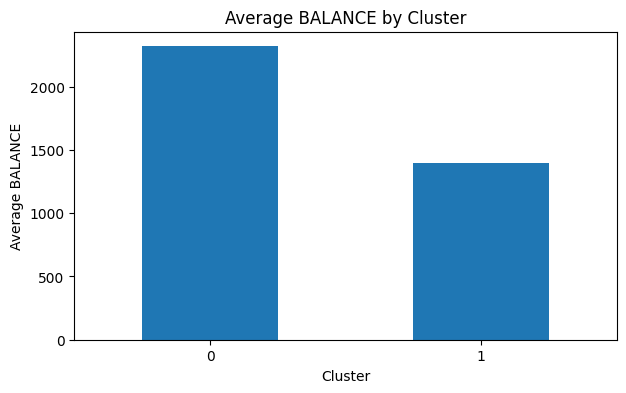

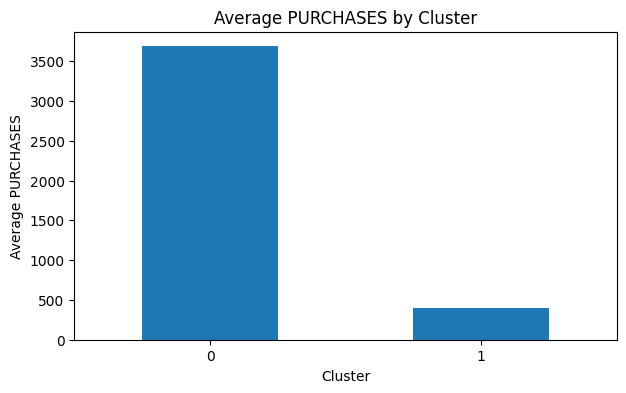

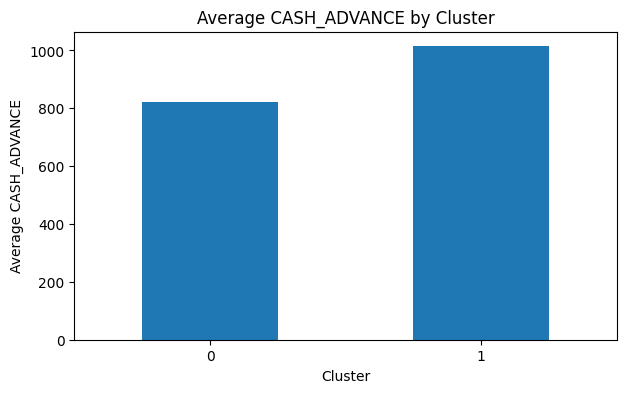

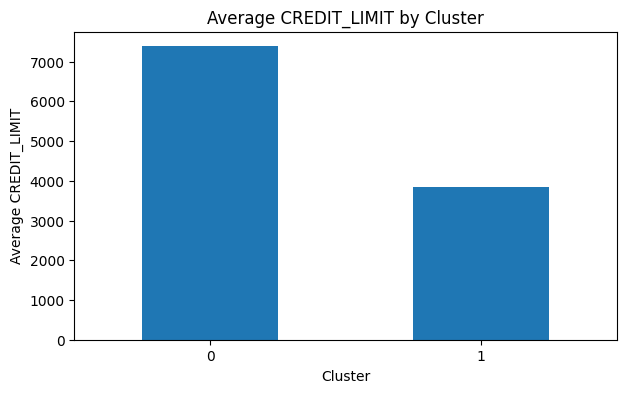

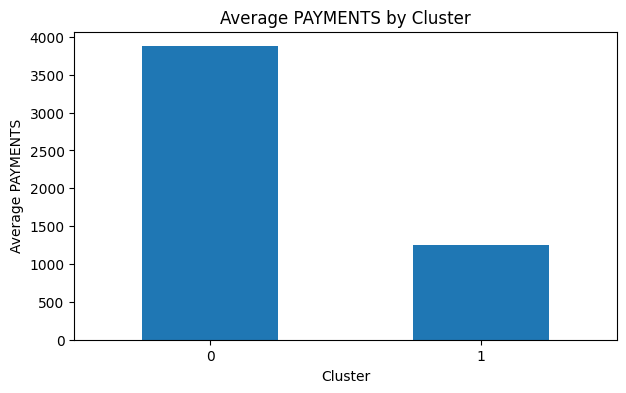

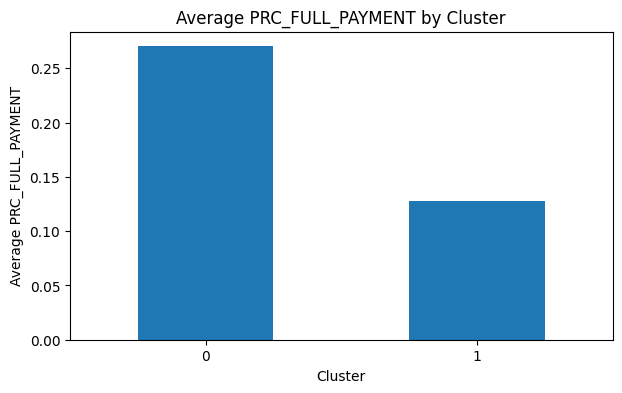

In [17]:
# ============================================================
# 17. Visualize selected cluster profiles
# ============================================================

selected_plot_features = [col for col in ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"] if col in cluster_profile.columns]

for feature in selected_plot_features:
    plt.figure(figsize=(7, 4))
    cluster_profile[feature].plot(kind="bar")
    plt.title(f"Average {feature} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(f"Average {feature}")
    plt.xticks(rotation=0)
    plt.show()

## 15. Cluster Interpretation

The following interpretation is generated from the cluster profile table. The labels are descriptive, not ground-truth labels, because clustering is unsupervised.

The interpretation focuses on customer spending, cash advance behavior, payment behavior, and credit usage.

In [18]:
# ============================================================
# 18. Generate simple cluster interpretation text
# ============================================================

def describe_cluster(row):
    """Generate a simple rule-based interpretation for one cluster profile."""
    descriptions = []

    if "PURCHASES" in row.index:
        if row["PURCHASES"] >= cluster_profile["PURCHASES"].median():
            descriptions.append("higher purchase activity")
        else:
            descriptions.append("lower purchase activity")

    if "CASH_ADVANCE" in row.index:
        if row["CASH_ADVANCE"] >= cluster_profile["CASH_ADVANCE"].median():
            descriptions.append("higher cash advance usage")
        else:
            descriptions.append("lower cash advance usage")

    if "PRC_FULL_PAYMENT" in row.index:
        if row["PRC_FULL_PAYMENT"] >= cluster_profile["PRC_FULL_PAYMENT"].median():
            descriptions.append("more frequent full payments")
        else:
            descriptions.append("less frequent full payments")

    if "CREDIT_LIMIT" in row.index:
        if row["CREDIT_LIMIT"] >= cluster_profile["CREDIT_LIMIT"].median():
            descriptions.append("higher credit limit")
        else:
            descriptions.append("lower credit limit")

    return ", ".join(descriptions)

cluster_interpretations = []
for cluster_id, row in cluster_profile.iterrows():
    interpretation = describe_cluster(row)
    cluster_interpretations.append({
        "cluster": cluster_id,
        "customer_count": int(row["customer_count"]),
        "interpretation": interpretation
    })

cluster_interpretation_df = pd.DataFrame(cluster_interpretations)
display(cluster_interpretation_df)

,cluster,customer_count,interpretation
0,0,1649,"higher purchase activity, lower cash advance u..."
1,1,7301,"lower purchase activity, higher cash advance u..."


## 16. MLflow Tracking

MLflow is used to track the clustering experiment, including:

- Dataset path
- Number of rows and features
- Number of clusters
- Clustering metrics
- Preprocessing decisions

This makes the experiment more reproducible and easier to document in the GitHub repository.

In [19]:
# ============================================================
# 19. MLflow tracking
# ============================================================

mlflow.set_experiment("UTS_Customer_Clustering")

with mlflow.start_run(run_name="kmeans_customer_segmentation"):
    mlflow.log_param("dataset_path", DATA_PATH)
    mlflow.log_param("dataset_rows", df.shape[0])
    mlflow.log_param("dataset_columns", df.shape[1])
    mlflow.log_param("removed_id_columns", ",".join(ID_COLS) if ID_COLS else "none")
    mlflow.log_param("removed_constant_columns", len(constant_cols))
    mlflow.log_param("number_of_features", len(numeric_cols))
    mlflow.log_param("outlier_lower_quantile", LOWER_Q)
    mlflow.log_param("outlier_upper_quantile", UPPER_Q)
    mlflow.log_param("best_n_clusters", best_k)

    mlflow.log_metric("inertia", final_inertia)
    mlflow.log_metric("silhouette_score", final_silhouette)
    mlflow.log_metric("davies_bouldin_score", final_db)
    mlflow.log_metric("calinski_harabasz_score", final_ch)

print("MLflow tracking completed.")

2026/05/15 12:41:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 12:41:27 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 12:41:29 INFO mlflow.tracking.fluent: Experiment with name 'UTS_Customer_Clustering' does not exist. Creating a new experiment.


MLflow tracking completed.


## 17. Save Output Artifacts

The clustered dataset, cluster profile, clustering evaluation table, alternative model comparison, and cluster interpretation are saved to Google Drive. These artifacts can be used later in the GitHub README.

In [20]:
# ============================================================
# 20. Save output artifacts
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/uts_clustering_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

clustered_path = os.path.join(OUTPUT_DIR, "clustered_customers.csv")
profile_path = os.path.join(OUTPUT_DIR, "cluster_profile.csv")
evaluation_path = os.path.join(OUTPUT_DIR, "cluster_evaluation.csv")
alternative_path = os.path.join(OUTPUT_DIR, "alternative_clustering_comparison.csv")
interpretation_path = os.path.join(OUTPUT_DIR, "cluster_interpretation.csv")

clustered_df.to_csv(clustered_path, index=False)
cluster_profile.to_csv(profile_path)
cluster_eval_df.to_csv(evaluation_path, index=False)
alternative_results_df.to_csv(alternative_path, index=False)
cluster_interpretation_df.to_csv(interpretation_path, index=False)

print("Clustered dataset saved to:", clustered_path)
print("Cluster profile saved to:", profile_path)
print("Cluster evaluation saved to:", evaluation_path)
print("Alternative clustering comparison saved to:", alternative_path)
print("Cluster interpretation saved to:", interpretation_path)

Clustered dataset saved to: /content/drive/MyDrive/uts_clustering_outputs/clustered_customers.csv
Cluster profile saved to: /content/drive/MyDrive/uts_clustering_outputs/cluster_profile.csv
Cluster evaluation saved to: /content/drive/MyDrive/uts_clustering_outputs/cluster_evaluation.csv
Alternative clustering comparison saved to: /content/drive/MyDrive/uts_clustering_outputs/alternative_clustering_comparison.csv
Cluster interpretation saved to: /content/drive/MyDrive/uts_clustering_outputs/cluster_interpretation.csv


## 18. Conclusion

This notebook successfully implements an end-to-end clustering pipeline for customer segmentation using credit card usage and payment behavior data.

The workflow includes dataset loading, EDA, missing value analysis, feature preparation, outlier handling, scaling, cluster number selection, Optuna tuning, K-Means training, alternative clustering comparison, PCA visualization, cluster profiling, interpretation, MLflow tracking, and artifact saving.

K-Means is selected as the final clustering model because it is simple, stable, and interpretable for customer segmentation. The final clusters are interpreted based on spending behavior, cash advance behavior, payment behavior, and credit limit.

Possible future improvements include experimenting with additional clustering algorithms, using advanced dimensionality reduction methods, or validating the clusters with business-specific customer behavior labels if available.